Lea Frost \
CSCE 580 \
Project A

# Module 1: Linear Regression

To write legible answers you will need to be familiar with both [Markdown](https://github.com/adam-p/markdown-here/wiki/Markdown-Cheatsheet) and [Latex](https://www.latex-tutorial.com/tutorials/amsmath/)

Before you turn this problem in, make sure everything runs as expected. First, restart the kernel (in the menubar, select Kernel→→Restart) and then run all cells (in the menubar, select Cell→→Run All).

Make sure you fill in any place that says "YOUR CODE HERE" or "YOUR ANSWER HERE", as well as your name below:

In [270]:
NAME = "Lea Frost"
STUDENT_ID = ""

import sys
!{sys.executable} -m pip install pandas

## Question 1 - Linear Regression
___
In this question, you will be implementing the linear regression algorithm from scratch in Python. Linear regression aims to map feature vectors to a continuous value in the range $[-\infty,+\infty]$ by linearly combining the feature values.

### Model Representation
Data is represented as a dataframe or a feature matrix. Let our feature matrix be $X$ whose dimensions are $n \times m$, $\theta$ be a weight matrix of dimensions $m \times 1$, the bias vector $b$ a column vector of dimension $m\times 1$. Using these we can predict $\hat{Y}$ by the following relationship:

$$\hat{Y} = X\theta + b$$

### Data: Facebook posts metrics

This data contains features describing posts from a cosmetic brand's Facebook page. The authors use the following features:

* Category,
* Page total likes: Number of people who have liked the company's page),
* Type: Type of content (Link, Photo, Status, Video),
* Post month: Month the post was published (January, February, March, …, December),
* Post hour: Hour the post was published (0, 1, 2, 3, 4, …, 23) ,
* Post weekday: Weekday the post was published (Sunday, Monday, …,
Saturday) ,
* Paid: If the company paid to Facebook for advertising (yes, no)

to model:

'Lifetime Post Total Reach', 'Lifetime Post Total Impressions', 'Lifetime Engaged Users', 'Lifetime Post Consumers',
'Lifetime Post Consumptions', 'Lifetime Post Impressions by people who have liked your Page', 'Lifetime Post reach by people who like your Page', 'Lifetime People who have liked your Page and engaged with your post', 'comment', 'like', 'share', 'Total Interactions'.


There are many possible features we could try to model, but we will focus on 'Total Interactions'. Our feature space will include: Category, Page total likes, Post month, Post hour, Post weekday, and Paid. We drop "Type" simply to avoid preprocessing.

You can read more about the dataset [here](http://archive.ics.uci.edu/ml/datasets/Facebook+metrics).






### Downloading the data

In [271]:
#!wget http://archive.ics.uci.edu/ml/machine-learning-databases/00368/Facebook_metrics.zip -O ./Facebook_metrics.zip
import zipfile
with zipfile.ZipFile('./Facebook_metrics.zip', 'r') as zip_ref:
    zip_ref.extractall('./')

### Reading in data

In [272]:
import pandas as pd
import numpy as np
np.random.seed(100)
'''
Shuffles the data in place
'''
def shuffle_data(data):
    np.random.shuffle(data)

# Read in the data
lr_dataframe = pd.read_csv('dataset_Facebook.csv',sep=';')
lr_dataframe.dropna(inplace=True)
columns_to_drop = ['Type','Lifetime Post Total Reach', 'Lifetime Post Total Impressions',
       'Lifetime Engaged Users', 'Lifetime Post Consumers',
       'Lifetime Post Consumptions',
       'Lifetime Post Impressions by people who have liked your Page',
       'Lifetime Post reach by people who like your Page',
       'Lifetime People who have liked your Page and engaged with your post',
       'comment', 'like', 'share']
lr_dataframe.drop(columns=columns_to_drop,inplace=True)

# Normalizing all remaining columns
def normalize_col(col):
    return (col - col.min())/(col.max() - col.min())

lr_dataframe = lr_dataframe.apply(normalize_col)

# Get entries as a numpy array
lr_data = lr_dataframe.values[:, :]

# Shuffle once for reproducibility
shuffle_data(lr_data)

lr_dataframe.head()

print(lr_dataframe.shape)

(495, 7)


### a) Splitting data in $X$ and $Y$
In this part we will write functions to split our data into a feature matrix X (augmented by a column of 1's to account for the bias term) and a column vector we wish to predict Y and further split X and Y into X_train, X_test, y_train and y_test for training and testing.

i) Split the dataset into $X$ and $Y$. In order to vectorize our calculations, we utilize the [bias trick](https://cs231n.github.io/linear-classify/). This simply means we need to append ones to our $X$ matrix.

ii) Split $X$ and $Y$ into the training and test sets using the provided percentage split (default is 80\% training and 20\% test).

In [273]:
'''
Combines one column of all ones and the matrix X to account for the bias term
(setting x_0 = 1) - [Hint: you may want to use np.hstack()]
Takes input matrix X
Returns the augmented input
'''
def bias_trick(X):
  # My code:
    X = np.hstack((np.ones((X.shape[0],1)),X))
    return X

'''
Separates feature vectors and targets
Takes raw data
Returns X as the matrix of feature vectors and Y as the vector of targets
'''
def separate_data(data):
    # Split into X (remember to use bias trick) and Y
    # My code:
    X = data[:, :-1]
    X = bias_trick(X)
    Y = data[:, -1]
    return X,Y


'''
Takes raw data in and splits the data into
X_train, y_train, X_test, y_test
Returns X_train, y_train, X_test, y_test
'''
def train_test_split(data, train_size=.80):
    # My code:
    split = int(data.shape[0] * train_size)
    #print(split)
    X,Y = separate_data(data)
    X_train = X[:split]
    X_test = X[split:]
    Y_train = Y[:split]
    Y_test = Y[split:]
    #print(X_train)
    #print(X_test)
    #print(Y_train)
    #print(Y_test)
    return X_train, Y_train, X_test, Y_test

### b) Training and testing our model
**Refer to the following derivation of the gradient when implementing linear regression and gradient descent below.**

For this question, we'll use and implement the Mean Squared Error (MSE), and gradient descent algorithm. Suppose our dataset consists of $n$ records, each with $d$ features:

$$X =
\begin{bmatrix}
    x_{1,1}       & x_{1,2} & \cdots & x_{1,d} \\
    x_{2,1}       & x_{2,2} & \cdots & x_{2,d} \\
    \vdots       & \vdots & \ddots & \vdots \\
    x_{n,1}       & x_{n,2} & \cdots & x_{n,d}
\end{bmatrix}$$

One way to include a bias is to augment $X$ with a column of ones:

$$X =
\begin{bmatrix}
    1 & x_{1,1}       & x_{1,2} & \cdots & x_{1,d} \\
    1 & x_{2,1}       & x_{2,2} & \cdots & x_{2,d} \\
    \vdots  & \vdots & \vdots & \ddots & \vdots \\
    1 & x_{n,1}       & x_{n,2} & \cdots & x_{n,d}
\end{bmatrix}$$

We also have $n$ labels corresponding to the correct classification of each of the above records, $y=[y_1,y_2,\cdots ,y_{n}]^T$, i.e.:

$$y =
\begin{bmatrix}
    y_1  \\
    y_2  \\
    \vdots   \\
    y_{n}
\end{bmatrix}$$

We will try to find the optimal parameter values $\theta = [\theta_0, \theta_1, \cdots, \theta_d]^T$ of our linear regression model, where $\theta_0$ is the bias weight. To simplify our notation, let

$$\hat{y} = X \theta =
\begin{bmatrix}
    X_{1,0}\theta_0 + X_{1,1}\theta_1 + \cdots + X_{1,d}\theta_d  \\
    X_{2,0}\theta_0 + X_{2,1}\theta_1 + \cdots + X_{2,d}\theta_d  \\
    \vdots   \\
    X_{n,0}\theta_0 + X_{n,1}\theta_1 + \cdots + X_{n,d}\theta_d
\end{bmatrix} =
\begin{bmatrix}
    \hat{y}_1  \\
    \hat{y}_2  \\
    \vdots   \\
    \hat{y}_{n}
\end{bmatrix}$$

We seek $\theta$ such that the MSE is minimized (the 1/2 factor makes the derivation easier). Let the MSE be a function of $\theta, J(\theta)$:

$$J(\theta) = \frac{1}{2n} \sum_{i=1}^{n} (\hat{y}_i - y_i)^2$$

Since the above is a convex function, it has a unique minimum value. Taking the derivative with respect to $\theta_i$, we get:

$$\frac{\partial}{\partial\theta_j}J(\theta) = \frac{1}{2n} \sum_{i=1}^{n} \frac{\partial}{\partial\theta_j}(\hat{y}_i - y_i)^2$$

$$\quad \quad \quad \quad= \frac{1}{n}\sum_{i=1}^{n} (\hat{y}_i - y_i) \frac{\partial}{\partial\theta_j} (\hat{y}_i)$$

Recall the chain rule from calculus, and that each $\hat{y}_i$ is a function of the $\theta_i$, so the above becomes:

$$\frac{\partial}{\partial\theta_j}J(\theta) = \frac{1}{n} \sum_{i=1}^{n} ( \hat{y_i} - y_i)x_{i,j}$$

YOU SHOULD:

i) Get training and testing set by calling train_test_split()

ii) Define a weight ($\theta$) vector

ii) Implement Gradient Descent using the information above

iii) Record the Sum Squared Error for training and test data

iv) Return the weight matrix, train errors and test errors

v) Plot the training and test errors and comment on the plot.

In [274]:
'''
Takes the target values and predicted values and calculates the squared error
between them
'''
def mse(y_pred, y_true):
  # My code:
    return np.mean((y_pred - y_true)**2)

'''
Implementation of the derivative of MSE.
Returns a vector of derivations of loss with respect to each of the dimensions
[\partial loss / \partial \theta_j]
'''
def mse_derivative(X,y,theta):
    # my code:
    n = len(y)
    y_pred = X.dot(theta)
    mse_d=0
    for i in range(n):
      mse_d += (y_pred[i] - y[i]) * X[i]
    return mse_d/n

'''
Gradient descent step.
Takes X, y, theta vector, and alpha.
Returns an updated theta vector.
'''
def gradient_descent_step(X,y, theta, alpha):
  # alpha is learning rate
  # theta are weights
  # mse derivative is gradient
    # my code:
    y_pred = X.dot(theta)
    theta -= alpha * mse_derivative(X,y,theta)
    return theta


def linear_regression(data, num_epochs=5000, alpha=0.0005):
    # Get training and testing set by calling train_test_split()
    # my code:
    X_train, Y_train ,X_test,Y_test = train_test_split(data)

    # Record training and test errors in lists
    train_errors= []
    test_errors= []

    # Define theta
    theta = np.zeros((X_train.shape[1]))
    #print(X_train)
    # Carry out training loop
    for i in range(num_epochs):
      # my code:
        train_error = mse(X_train.dot(theta), Y_train)
        train_errors.append(train_error)
      # my code:
        test_error = mse(X_test.dot(theta), Y_test)
        test_errors.append(test_error)

        # Do gradient descent on the training set
        theta = gradient_descent_step(X_train, Y_train, theta, alpha)
    return theta, train_errors, test_errors

<>:12: SyntaxWarning: invalid escape sequence '\p'
<>:12: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipython-input-1499645952.py:12: SyntaxWarning: invalid escape sequence '\p'
  [\partial loss / \partial \theta_j]


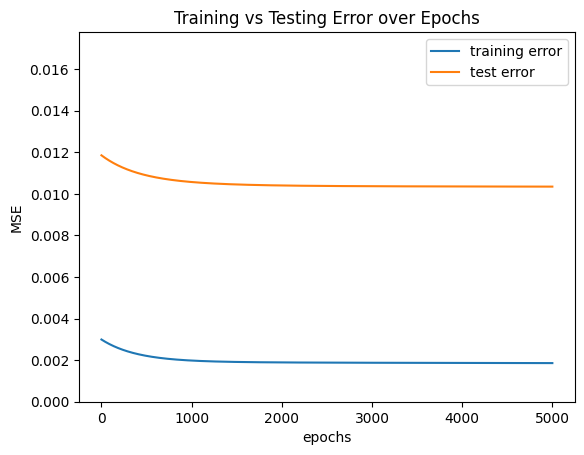

In [275]:
# Carry out training task
# my code
theta, train_errors, test_errors = linear_regression(lr_data)

# Plot the training error and test error for different epochs (iterations of the
# algorithm). Your plot be MSE error vs epochs.
# my code:
plt.plot(train_errors, label='training error')
plt.plot(test_errors, label='test error')
plt.xlabel('epochs')
plt.ylabel('MSE')
plt.ylim(0, max(train_errors[0], test_errors[0])*1.5)
plt.title('Training vs Testing Error over Epochs')
plt.legend()
plt.show()